# I - Libraries

In [1]:
# Import libraries
import numpy as np                                      # Calculating tools
import pandas as pd                                     # Data manipulation
import scipy.stats as stats                             # Statistics tools
import matplotlib.pyplot as plt                         # Data visualization
import seaborn as sns                                   # Modern data visualization
import plotly.graph_objects as go                       # Interactive visualization

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder   # Encode categorical variable,  Data normalization
from sklearn.model_selection import train_test_split                             # Create train, test set         
from sklearn import datasets                                                     # Some sample data sets 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA      # LDA model
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA   # QDA model
from sklearn.neighbors import KNeighborsClassifier                               # kNN model 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


import statsmodels.api as sm                     # Statistical models
import statsmodels.formula.api as smf            # Statistical models with formula supports
import ISLP 


# II- Data Exploration & Cleaning

## A) Loading the data

In [2]:
import os
print(os.getcwd())          # shows current notebook directory
print(os.listdir('Data'))   # shows contents of the Data folder

c:\Users\Source\Desktop\kaggle comp
['sample_submission.csv', 'test.csv', 'train.csv', 'train_labels.csv']


In [3]:
train = pd.read_csv('Data/train.csv', index_col=0)
train_labels = pd.read_csv('Data/train_labels.csv', index_col=0)
test = pd.read_csv('Data/test.csv', index_col=0)

C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2079969306.py:1: DtypeWarning: Columns (14742,14743,14749,14750,14751,14753,14754,14756,14759,14760,14761,14763,14768,14770,14774,14777,14780,14781,14782,14790,14792,14798,14799,14801,14805,14806,14807,14810,14812,14818,14819,14820,14825,14829,14833,14835,14837,14844,14845,14851,14852,14856,14862,14872,14877,14879,14880,14882,14883,14884,14887,14889,14891,14895,14897,14898,14901,14905,14907,14915,14917,14918,14919,14927,14929,14932,14933,14937,14938,14940,14943,14945,14948,14952,14955,14958,14959,14971,14973,14981,14997,14999) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('Data/train.csv', index_col=0)
C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2079969306.py:3: DtypeWarning: Columns (14742,14743,14749,14750,14751,14753,14754,14756,14759,14760,14761,14763,14768,14770,14774,14777,14780,14781,14782,14790,14792,14798,14799,14801,14805,14806,14807,14810,14812,14818,14819,14820,14825,

We verify that the data was loaded correclty

In [4]:
train.head(3)

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14991,Var14992,Var14993,Var14994,Var14995,Var14996,Var14997,Var14998,Var14999,Var15000
ID,,,,,,,,,,,,,,,,,,,,,
502504,0,0,0,0,6,0,0.0,0,0,0,...,NaN,NaN,Y562h9T,NaN,Q8_a,Xjzr,NaN,NaN,NaN,NaN
197332,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,NyGn9rV,NaN,Q8_a,NBRvrWWx0Z,NaN,NaN,NaN,NaN
277830,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,Kbs60Tf,NaN,Q8_a,NBRvrWWx0Z,NaN,GD6M5hO,NaN,NaN


In [5]:
train_labels.head(3)

,Target_appetency
ID,
502504,0
197332,0
277830,0


In [6]:
test.head(3)

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14991,Var14992,Var14993,Var14994,Var14995,Var14996,Var14997,Var14998,Var14999,Var15000
ID,,,,,,,,,,,,,,,,,,,,,
877149,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,oHCnpDP,NaN,KttQ,NBRvrWWx0Z,NaN,GD6M5hO,NaN,NaN
109603,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,WHgQeH3,NaN,KttQ,lGxM0UqL0k,NaN,NaN,NaN,NaN
560424,0,0,0,0,0,0,0.0,0,0,0,...,NaN,NaN,COVmcoL,NaN,Q8_a,NBRvrWWx0Z,NaN,NaN,NaN,NaN


In [ ]:
# Merging the training set 

#train = train.merge(train_labels, on='ID', how='left')

## B) Data Exploration

Performing Basic Data Exploration

### Exploration Function

In [7]:
def explore(dataset, name = "dataset"):
    print(f'{name} set : ')
    # Shape
    print(f'Rows    : {dataset.shape[0]}')
    print(f'Columns : {dataset.shape[1]}')
    # Dtypes
    print(f'\nDtypes breakdown:')
    print(dataset.dtypes.value_counts())
    # Columns type
    num_cols = dataset.select_dtypes(include='number').columns
    cat_cols = dataset.select_dtypes(include='object').columns
    
    print(f"Numeric columns   : {len(num_cols)}")
    print(f"Categorical cols  : {len(cat_cols)}")

    # Check for duplicates
    duplicates = dataset.duplicated().sum()
    print(f'Duplicates : {duplicates}')


In [8]:
# Train set
explore(train, name = "Train")

Train set : 
Rows    : 30000
Columns : 15000

Dtypes breakdown:
int64      13414
float64     1397
object       189
Name: count, dtype: int64
Numeric columns   : 14811
Categorical cols  : 189
Duplicates : 0


In [9]:
# Train Labels
explore(train_labels, name='Train Labels')

Train Labels set : 
Rows    : 30000
Columns : 1

Dtypes breakdown:
int64    1
Name: count, dtype: int64
Numeric columns   : 1
Categorical cols  : 0
Duplicates : 29998


Repeated labels are expected since this is a classification dataset (many samples share the same target value)

In [10]:
# Test set
explore(test, name = 'Test')

Test set : 
Rows    : 20000
Columns : 15000

Dtypes breakdown:
int64      13414
float64     1397
object       189
Name: count, dtype: int64
Numeric columns   : 14811
Categorical cols  : 189
Duplicates : 0


We notice that we only have 189 categorical variables.  
However, according to the data description, we are supossed to find 260 categorical variables.  
Hence, we need to check where the problem is and correct the problem accordingly

In [11]:
# We verify the dtype of the 260 categorical variables
print('Train : ' , train.iloc[:, 14741:].dtypes.unique())
print('Test : ', test.iloc[:, 14741:].dtypes.unique())

Train :  [dtype('O') dtype('float64')]
Test :  [dtype('O') dtype('float64')]


We can see that some of these features are casted as floats. We need to cast them back as objects

In [12]:
# Casting for train
train[train.columns[14741 :]] = train[train.columns[14741 :]].astype('object')

# Casting for test
test[test.columns[14741 :]] = test[test.columns[14741 :]].astype('object')

# Checking 
print('Train : ' , train.iloc[:, 14741:].dtypes.unique())
print('Test : ', test.iloc[:, 14741:].dtypes.unique())

Train :  [dtype('O')]
Test :  [dtype('O')]


We verify that we have the right distrobution of dtypes

In [13]:
# Train set
explore(train, name = "Train")

Train set : 
Rows    : 30000
Columns : 15000

Dtypes breakdown:
int64      13414
float64     1326
object       260
Name: count, dtype: int64
Numeric columns   : 14740
Categorical cols  : 260
Duplicates : 0


In [14]:
# Test set
explore(test, name = 'Test')

Test set : 
Rows    : 20000
Columns : 15000

Dtypes breakdown:
int64      13414
float64     1326
object       260
Name: count, dtype: int64
Numeric columns   : 14740
Categorical cols  : 260
Duplicates : 0


C:\Users\Source\AppData\Local\Temp\ipykernel_20452\860976034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dist_pct,


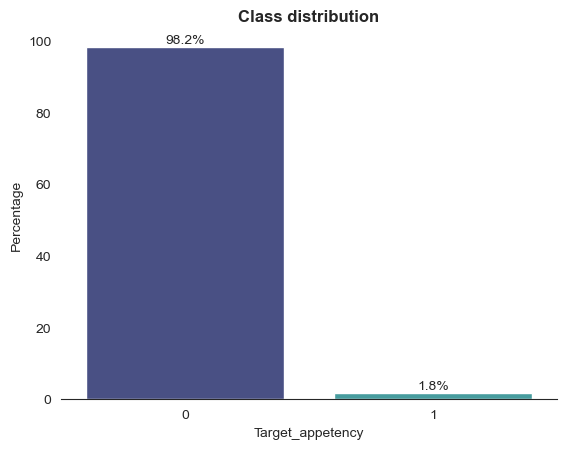

In [15]:
# Checking class balance
dist_pct    =  train_labels['Target_appetency'].value_counts(normalize=True) * 100
dist_pct = dist_pct.reset_index()
dist_pct.columns = ['Target_appetency', 'Percentage']

sns.set_style("white")

ax = sns.barplot(data=dist_pct,
            x = 'Target_appetency',
            y = 'Percentage',
            palette='mako')

for p in ax.patches:
    ax.text(
        x=p.get_x() + p.get_width()/2,  # center of bar
        y=p.get_height() + 1,           # slightly above bar
        s=f'{p.get_height():.1f}%',     # text
        ha='center'
    )

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)


plt.title('Class distribution', fontweight='bold')
plt.show()

We notice that the data is **highly imbalanced.**  
This will be handled later when modeling.

## C) Data Cleaning and Pre-Processing

#### Defining Functions

In [16]:
def missing_values(dataset, name='dataset'):
    total_missing = dataset.isna().sum().sum()
    print(f'Total missing values in {name} dataset: {total_missing}')
    
    if total_missing > 0:
        print('='*40)
        
        # Missing percentage per column
        missing_pct = dataset.isna().mean() * 100
        
        # 100% missing columns
        full_missing = missing_pct[missing_pct == 100]
        print(f'\nColumns with 100% missing: {len(full_missing)}')
        if len(full_missing) > 0:
            print(full_missing.index.tolist())
        
        # >50% missing columns
        high_missing = missing_pct[missing_pct > 50]
        print(f'\nColumns with >50% missing: {len(high_missing)}')
        if len(high_missing) > 0:
            print(high_missing.sort_values(ascending=False))
        
        print('\n' + '='*40)
        
        # breakdown by type
        num_cols = dataset.select_dtypes(include='number').columns
        cat_cols = dataset.select_dtypes(include='object').columns
        
        print(f'\nNumerical columns with missing: {dataset[num_cols].isna().any().sum()}')
        print(f'Categorical columns with missing: {dataset[cat_cols].isna().any().sum()}')
    
    else:
        print("No missing values")

In [17]:
def cleaning_missing(dataset, name = 'dataset', threshold = 50, missing_flag = True):
    # Handling columns with 100% missing values 

    # Numeric
    num_cols = dataset.select_dtypes(include='number').columns
    num_missing_pct = dataset[num_cols].isna().mean() * 100
    drop_num = num_missing_pct[num_missing_pct >= threshold].index

    # Categorical
    cat_cols = dataset.select_dtypes(exclude='number').columns
    cat_missing_pct = dataset[cat_cols].isna().mean() * 100
    drop_cat = cat_missing_pct[cat_missing_pct >= threshold].index

    # Drop
    dataset.drop(columns=list(drop_num) + list(drop_cat), inplace=True)

    # Handling columns with more than 50% missing values

    num_cols = dataset.select_dtypes(include='number').columns
    cat_cols = dataset.select_dtypes(exclude='number').columns

    # create missing flags
    if missing_flag:
        for col in list(num_cols) + list(cat_cols):
            if dataset[col].isna().sum() > 0:
                dataset[col + '_missing'] = dataset[col].isna().astype(int)

    # Numeric: fill NaN with median
    for col in num_cols:
        median_val = dataset[col].median()
        dataset[col].fillna(median_val, inplace=True)

    # Categorical: fill NaN with 'missing'
    for col in cat_cols:
        dataset[col].fillna('missing', inplace=True)

    # Check
    total_missing = dataset.isna().sum().sum()
    print(f"After cleaning, total missing values in {name}: {total_missing}")

    return dataset

### Train Set

#### Missing Values

x Train

In [18]:
missing_values(train, name = 'Train')

Total missing values in Train dataset: 15068446

Columns with 100% missing: 109
['Var52', 'Var156', 'Var269', 'Var1103', 'Var1327', 'Var2091', 'Var2502', 'Var3140', 'Var3488', 'Var4166', 'Var4314', 'Var4790', 'Var5135', 'Var5255', 'Var6194', 'Var6974', 'Var7129', 'Var7222', 'Var7315', 'Var7912', 'Var9057', 'Var9903', 'Var10776', 'Var11143', 'Var11476', 'Var11530', 'Var11560', 'Var11728', 'Var11729', 'Var12170', 'Var12749', 'Var13198', 'Var13243', 'Var13292', 'Var13820', 'Var14137', 'Var14197', 'Var14316', 'Var14744', 'Var14757', 'Var14764', 'Var14775', 'Var14779', 'Var14783', 'Var14787', 'Var14789', 'Var14793', 'Var14794', 'Var14796', 'Var14804', 'Var14808', 'Var14814', 'Var14816', 'Var14824', 'Var14826', 'Var14827', 'Var14828', 'Var14830', 'Var14831', 'Var14840', 'Var14843', 'Var14848', 'Var14849', 'Var14853', 'Var14855', 'Var14857', 'Var14858', 'Var14861', 'Var14864', 'Var14870', 'Var14881', 'Var14886', 'Var14899', 'Var14902', 'Var14908', 'Var14911', 'Var14920', 'Var14924', 'Var14925

In [19]:
cleaning_missing(train, name = 'Train', threshold = 50, missing_flag = True)

C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2267604098.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset[col + '_missing'] = dataset[col].isna().astype(int)
C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2267604098.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset[col + '_missing'] = dataset[col].isna().astype(int)
C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2267604098.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many time

After cleaning, total missing values in Train: 0


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14871_missing,Var14885_missing,Var14904_missing,Var14965_missing,Var14969_missing,Var14970_missing,Var14984_missing,Var14989_missing,Var14995_missing,Var14996_missing
ID,,,,,,,,,,,,,,,,,,,,,
502504,0,0,0,0,6,0,0.0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
197332,0,0,0,0,0,0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
277830,0,0,0,0,0,0,0.0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
247676,0,0,0,0,0,0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
972007,0,0,0,0,0,0,0.0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625358,0,0,0,0,0,0,0.0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
382670,0,0,0,0,0,0,0.0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
209811,0,0,0,0,0,0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


y Train

In [20]:
missing_values(train_labels, name = 'Train Labels')

Total missing values in Train Labels dataset: 0
No missing values


#### One Hot Encoding and Scaling

In [21]:
print(train.shape)
print(test.shape)
print(train.dtypes.value_counts())

(30000, 14561)
(20000, 15000)
int64      13501
float64     1024
object        36
Name: count, dtype: int64


Encoding our categorical features and scaling the numerical ones before modeling

In [22]:
# Step 1: identify column types
cat_cols = train.select_dtypes(exclude='number').columns
num_cols = train.select_dtypes(include='number').columns

# Step 2: filter cat cols — remove flags and high cardinality (OPTIONS 1 & 2)
flag_cols = [c for c in cat_cols if train[c].dropna().isin([0, 1]).all()]
cat_cols_filtered = [c for c in cat_cols if c not in flag_cols and train[c].nunique() <= 10]
print(f"original cat cols: {len(cat_cols)}, after filtering: {len(cat_cols_filtered)}, removed: {len(cat_cols) - len(cat_cols_filtered)}")

# Step 3: encode filtered categoricals only
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded = encoder.fit_transform(train[cat_cols_filtered])
train_encoded_df = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(cat_cols_filtered), index=train.index)

# Step 4: scale numerics
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train[num_cols])
train_scaled_df = pd.DataFrame(train_scaled, columns=num_cols, index=train.index)

# Step 5: combine
train_final = pd.concat([train_scaled_df, train_encoded_df], axis=1)
print(f"train_final shape: {train_final.shape}")

original cat cols: 36, after filtering: 16, removed: 20
train_final shape: (30000, 14593)


### Test Set

#### Missing Values

In [23]:
missing_values(test, name = 'Test')

Total missing values in Test dataset: 10040123

Columns with 100% missing: 110
['Var52', 'Var156', 'Var269', 'Var1103', 'Var1327', 'Var2091', 'Var2502', 'Var3140', 'Var3488', 'Var4166', 'Var4314', 'Var4790', 'Var5135', 'Var5255', 'Var6194', 'Var6974', 'Var7129', 'Var7222', 'Var7315', 'Var7912', 'Var9057', 'Var9903', 'Var10776', 'Var10906', 'Var11143', 'Var11476', 'Var11530', 'Var11560', 'Var11728', 'Var11729', 'Var12170', 'Var12749', 'Var13198', 'Var13243', 'Var13292', 'Var13820', 'Var14137', 'Var14197', 'Var14316', 'Var14744', 'Var14757', 'Var14764', 'Var14775', 'Var14779', 'Var14783', 'Var14787', 'Var14789', 'Var14793', 'Var14794', 'Var14796', 'Var14804', 'Var14808', 'Var14814', 'Var14816', 'Var14824', 'Var14826', 'Var14827', 'Var14828', 'Var14830', 'Var14831', 'Var14840', 'Var14843', 'Var14848', 'Var14849', 'Var14853', 'Var14855', 'Var14857', 'Var14858', 'Var14861', 'Var14864', 'Var14870', 'Var14881', 'Var14886', 'Var14899', 'Var14902', 'Var14908', 'Var14911', 'Var14920', 'Var14924'

In [24]:
cleaning_missing(test, name = 'Test', threshold = 50, missing_flag = True)

C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2267604098.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset[col + '_missing'] = dataset[col].isna().astype(int)
C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2267604098.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset[col + '_missing'] = dataset[col].isna().astype(int)
C:\Users\Source\AppData\Local\Temp\ipykernel_20452\2267604098.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many time

After cleaning, total missing values in Test: 0


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var14885_missing,Var14904_missing,Var14913_missing,Var14965_missing,Var14969_missing,Var14970_missing,Var14984_missing,Var14989_missing,Var14995_missing,Var14996_missing
ID,,,,,,,,,,,,,,,,,,,,,
877149,0,0,0,0,0,0,0.0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
109603,0,0,0,0,0,0,0.0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
560424,0,0,0,0,0,0,0.0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
386592,0,0,0,0,0,0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
857379,0,0,0,0,0,0,0.0,0,0,0,...,1,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385388,0,0,0,0,0,0,0.0,0,0,0,...,0,0,0,0,1,1,0,0,0,1
166874,0,0,0,0,0,0,0.0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
146405,0,0,0,0,6,0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### One Hot Encoding and Scaling

In [25]:
# transform only, using fitted encoder and scaler
test_encoded = encoder.transform(test[cat_cols_filtered])
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(cat_cols_filtered), index=test.index)

test_scaled = scaler.transform(test[num_cols])
test_scaled_df = pd.DataFrame(test_scaled, columns=num_cols, index=test.index)

test_final = pd.concat([test_scaled_df, test_encoded_df], axis=1)
print(f"test_final shape: {test_final.shape}")

test_final shape: (20000, 14593)


In [26]:
y = train_labels['Target_appetency']
X = train_final
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# III - Modeling